In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, AdamW, Nadam

import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('processed_variant_13.csv')
X = df.drop(columns=['BMI'])
y = df['BMI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
input_shape = (X_train.shape[1],)

print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір тренувальної вибірки: (240, 6)
Розмір тестової вибірки: (60, 6)


In [10]:
model_configs = [
    {"name": "M1_16_8_4_Elu_Adam", "units": [16, 8, 4], "activation": "elu", "optimizer": "adam", "dropout": 0.0, "bn": False},
    {"name": "M2_16_8_4_Elu_AdamW", "units": [16, 8, 4], "activation": "elu", "optimizer": "adamw", "dropout": 0.0, "bn": False},
    {"name": "M3_16_8_4_Elu_Nadam", "units": [16, 8, 4], "activation": "elu", "optimizer": "nadam", "dropout": 0.0, "bn": False},

    {"name": "M4_8_8_4_Gelu_Adam", "units": [8, 8, 4], "activation": "gelu", "optimizer": "adam", "dropout": 0.0, "bn": False},
    {"name": "M5_8_8_4_Gelu_AdamW", "units": [8, 8, 4], "activation": "gelu", "optimizer": "adamw", "dropout": 0.0, "bn": False},
    {"name": "M6_8_8_4_Gelu_Nadam", "units": [8, 8, 4], "activation": "gelu", "optimizer": "nadam", "dropout": 0.0, "bn": False},

    {"name": "M7_8_8_4_Gelu_Adam_Dropout_Bn", "units": [8, 8, 4], "activation": "gelu", "optimizer": "adam", "dropout": 0.2, "bn": True},
    {"name": "M8_8_8_4_Gelu_AdamW_Dropout_Bn", "units": [8, 8, 4], "activation": "gelu", "optimizer": "adamw", "dropout": 0.2, "bn": True},
    {"name": "M9_8_8_4_Gelu_Nadam_Dropout_Bn", "units": [8, 8, 4], "activation": "gelu", "optimizer": "nadam", "dropout": 0.2, "bn": True},

    {"name": "M10_16_16_16_Relu_Adam", "units": [16, 16, 16], "activation": "relu", "optimizer": "adam", "dropout": 0.0, "bn": False},
    {"name": "M11_16_16_16_Relu_AdamW", "units": [16, 16, 16], "activation": "relu", "optimizer": "adamw", "dropout": 0.0, "bn": False},
    {"name": "M12_16_16_16_Relu_Nadam", "units": [16, 16, 16], "activation": "relu", "optimizer": "nadam", "dropout": 0.0, "bn": False},

    {"name": "M13_32_16_8_Gelu_AdamW_Dropout_Bn", "units": [32, 16, 8], "activation": "gelu", "optimizer": "adamw", "dropout": 0.2, "bn": True},
    {"name": "M14_8_4_Relu_Nadam_Dropout_Bn", "units": [8, 4], "activation": "relu", "optimizer": "nadam", "dropout": 0.2, "bn": True},
]

In [11]:
def build_model(config, input_shape):
    model = Sequential(name=config["name"])
    model.add(Input(shape=input_shape))

    for units in config["units"]:
        model.add(Dense(units, activation=config["activation"]))
        if config["bn"]:
            model.add(BatchNormalization())
        if config["dropout"] > 0.0:
            model.add(Dropout(config["dropout"]))

    model.add(Dense(1, name='output'))

    opt_name = config["optimizer"].lower()
    lr = 0.001

    if opt_name == "adam":
        opt = Adam(learning_rate=lr)
    elif opt_name == "adamw":
        opt = AdamW(learning_rate=lr, weight_decay=0.004)
    elif opt_name == "nadam":
        opt = Nadam(learning_rate=lr)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

In [12]:
results = []
trained_models = {}
EPOCHS = 100
BATCH_SIZE = 32

print(f"Початок навчання {len(model_configs)} мереж...\n")

for config in model_configs:
    model = build_model(config, input_shape)
    print(f"{model.name}...")

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )

    y_pred = model.predict(X_test, verbose=0).flatten()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({'Model': model.name, 'MAE': mae, 'MSE': mse, 'R2': r2})
    trained_models[model.name] = (model, y_pred)

print("\nНавчання завершено.")

Початок навчання 14 мереж...

M1_16_8_4_Elu_Adam...
M2_16_8_4_Elu_AdamW...
M3_16_8_4_Elu_Nadam...
M4_8_8_4_Gelu_Adam...
M5_8_8_4_Gelu_AdamW...
M6_8_8_4_Gelu_Nadam...
M7_8_8_4_Gelu_Adam_Dropout_Bn...
M8_8_8_4_Gelu_AdamW_Dropout_Bn...
M9_8_8_4_Gelu_Nadam_Dropout_Bn...
M10_16_16_16_Relu_Adam...
M11_16_16_16_Relu_AdamW...
M12_16_16_16_Relu_Nadam...
M13_32_16_8_Gelu_AdamW_Dropout_Bn...
M14_8_4_Relu_Nadam_Dropout_Bn...

Навчання завершено.


In [13]:
from IPython.display import display

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)

print("Фінальні результати нейронних мереж:")
display(results_df)

Фінальні результати нейронних мереж:


,Model,MAE,MSE,R2
0,M1_16_8_4_Elu_Adam,0.189336,0.061038,0.927384
5,M6_8_8_4_Gelu_Nadam,0.193360,0.062622,0.925500
3,M4_8_8_4_Gelu_Adam,0.197932,0.063106,0.924924
4,M5_8_8_4_Gelu_AdamW,0.203634,0.065582,0.921979
2,M3_16_8_4_Elu_Nadam,0.202039,0.066627,0.920736
1,M2_16_8_4_Elu_AdamW,0.203023,0.067180,0.920078
9,M10_16_16_16_Relu_Adam,0.205612,0.072244,0.914053
10,M11_16_16_16_Relu_AdamW,0.218717,0.074981,0.910796
11,M12_16_16_16_Relu_Nadam,0.219578,0.080261,0.904515
12,M13_32_16_8_Gelu_AdamW_Dropout_Bn,0.263035,0.102260,0.878343


Побудова графіків...


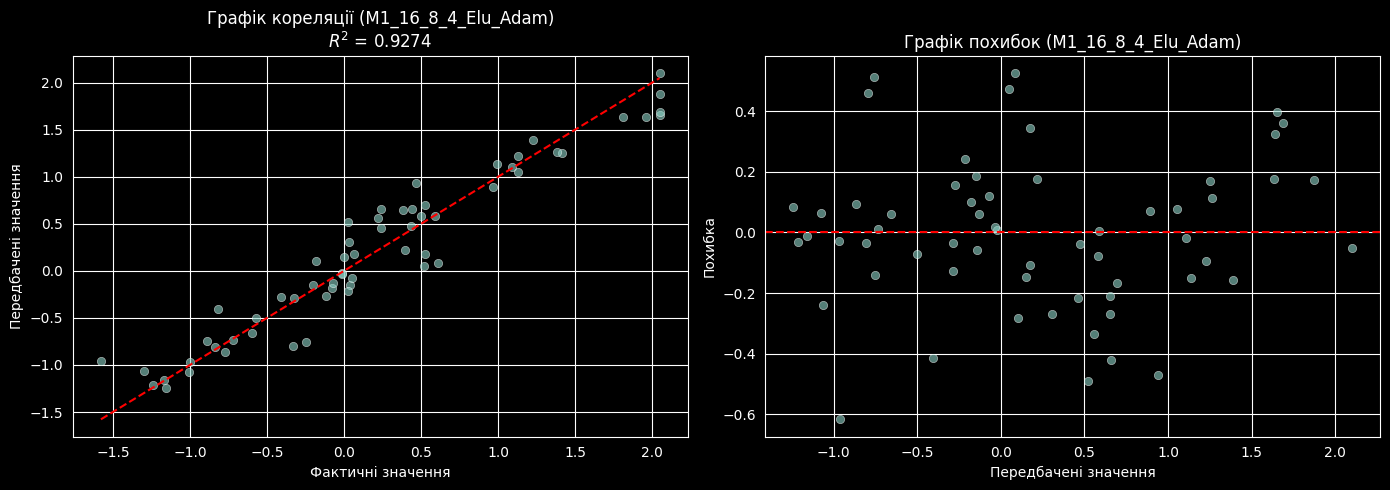

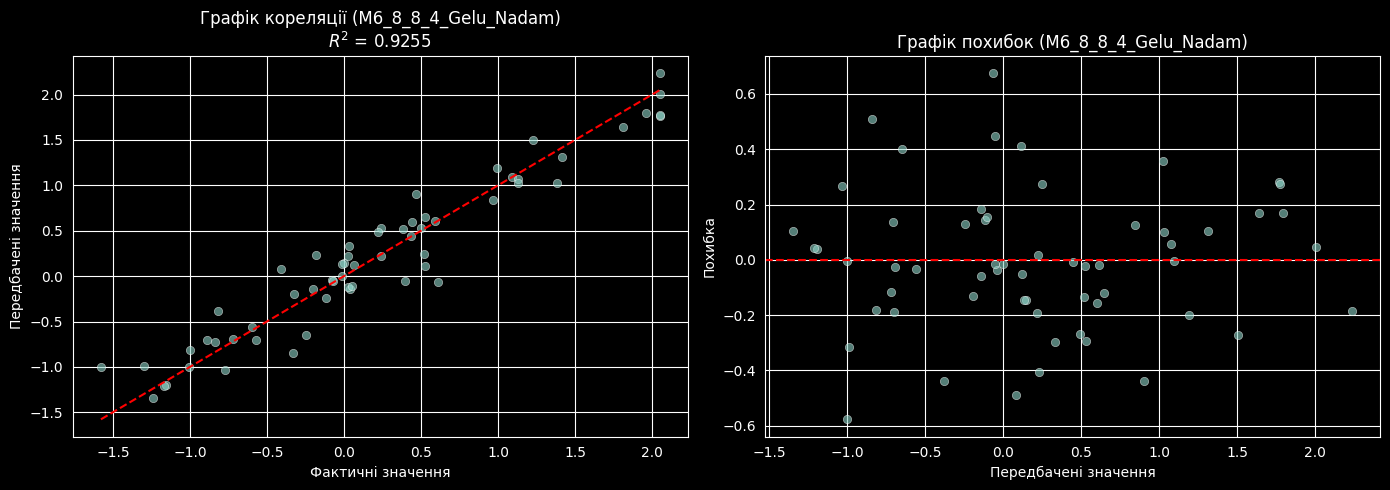

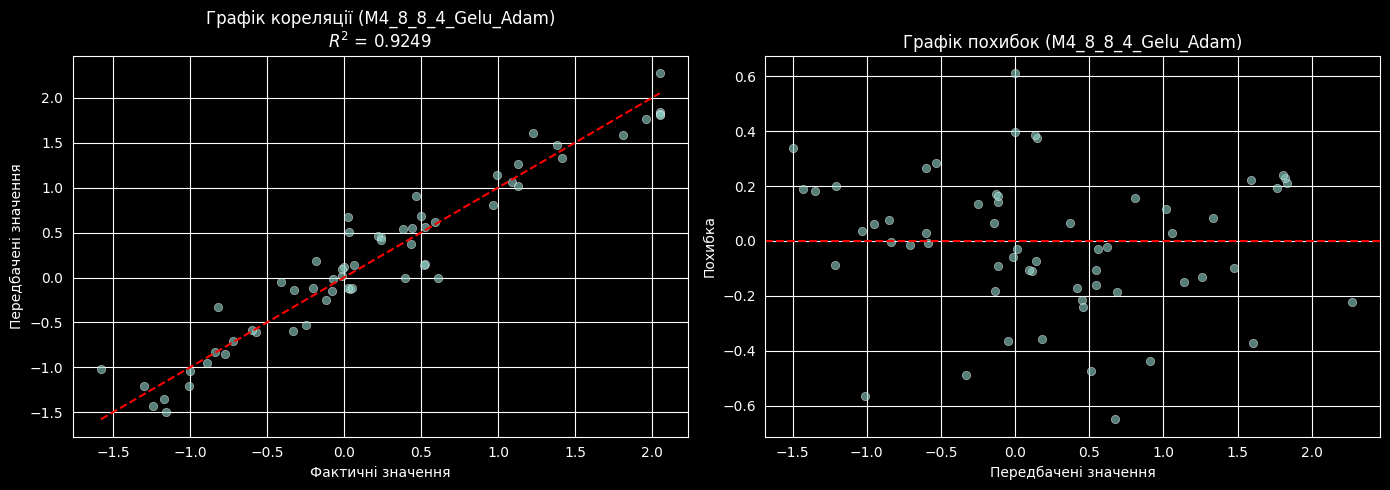

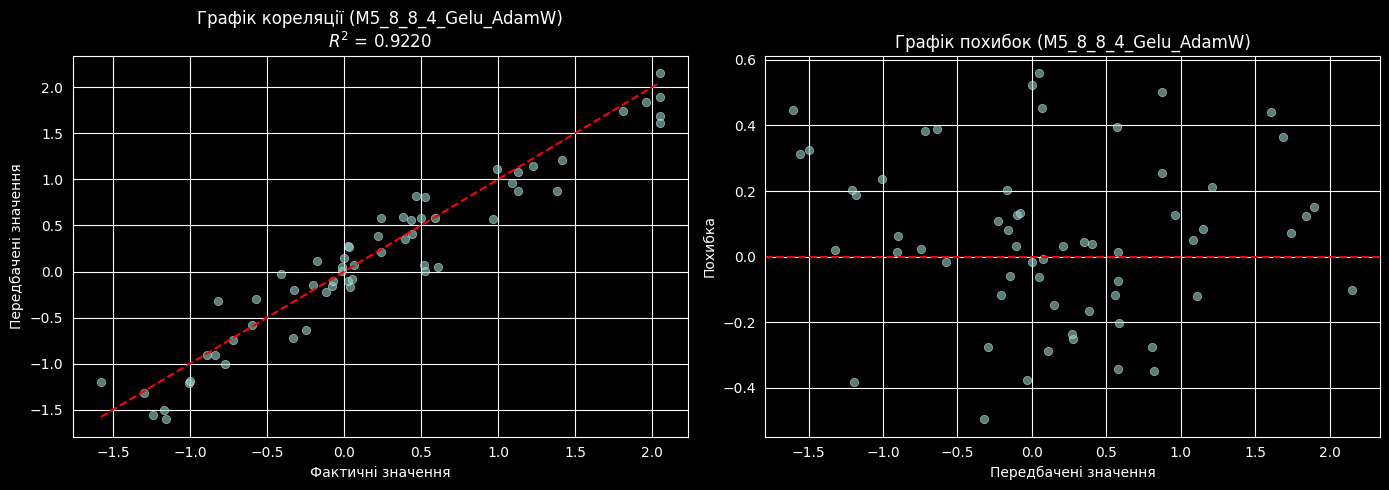

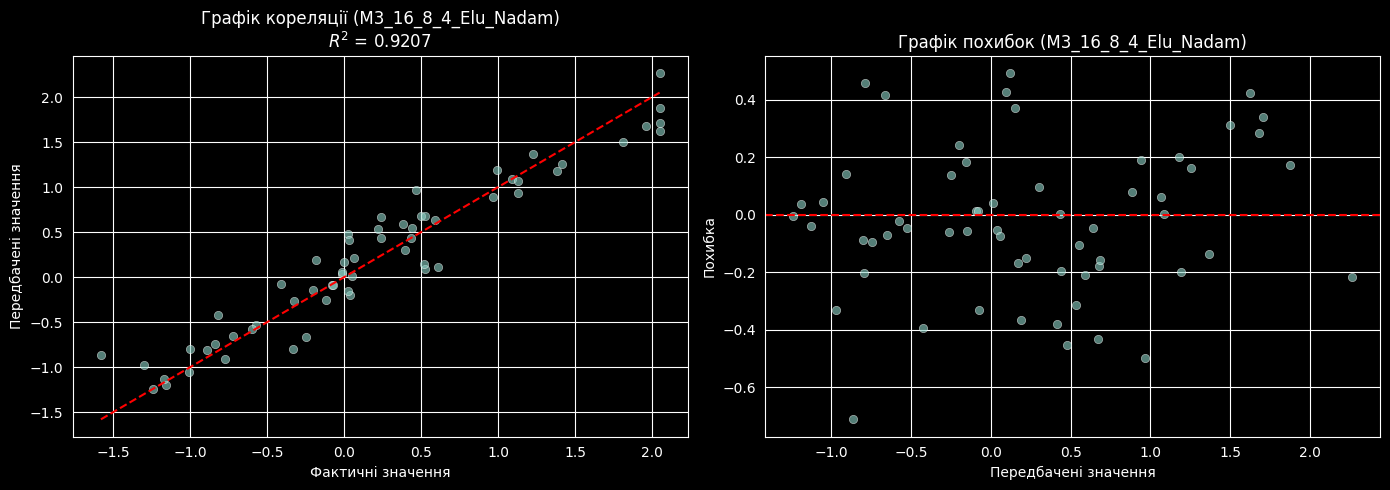

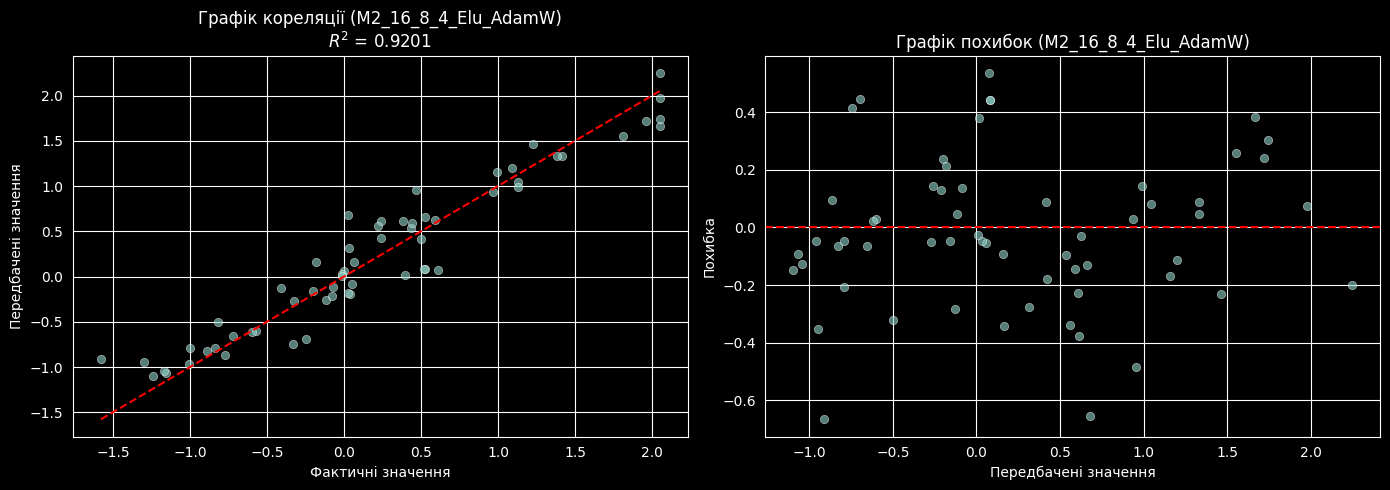

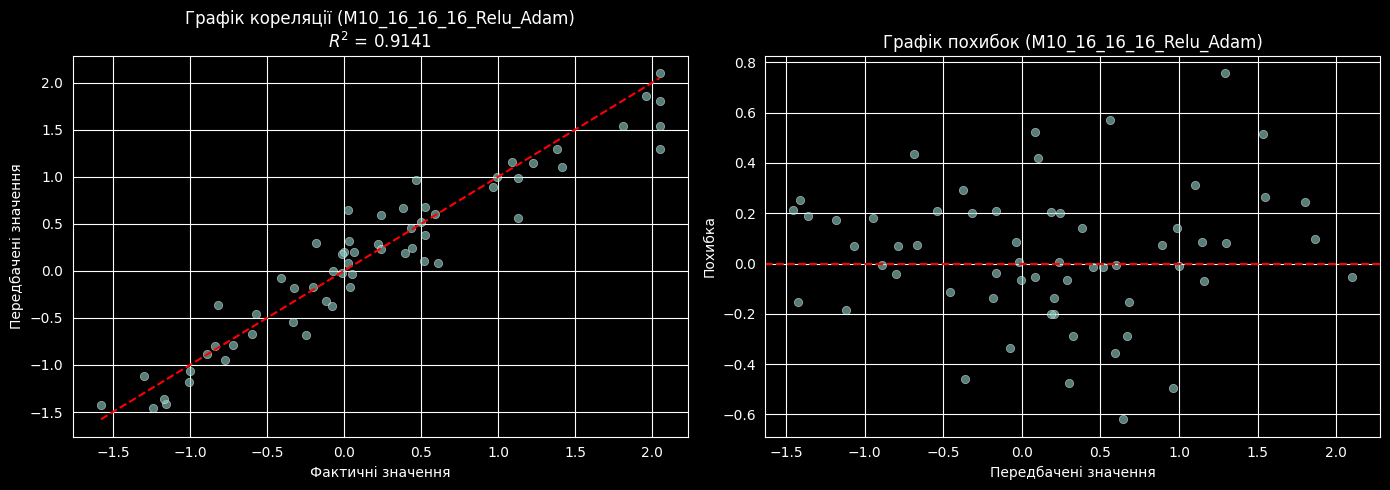

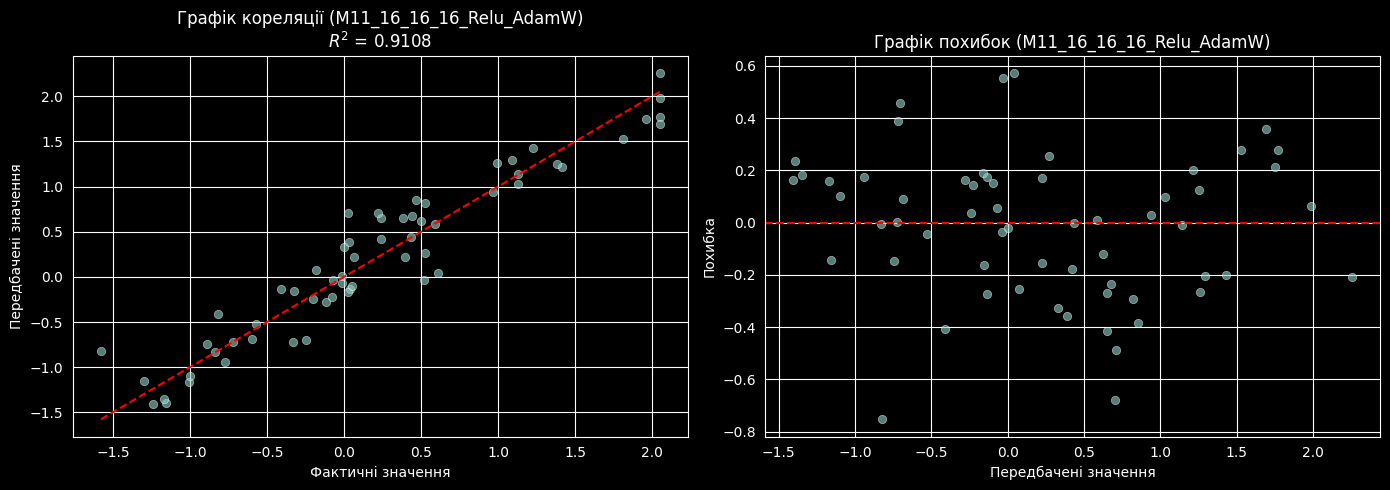

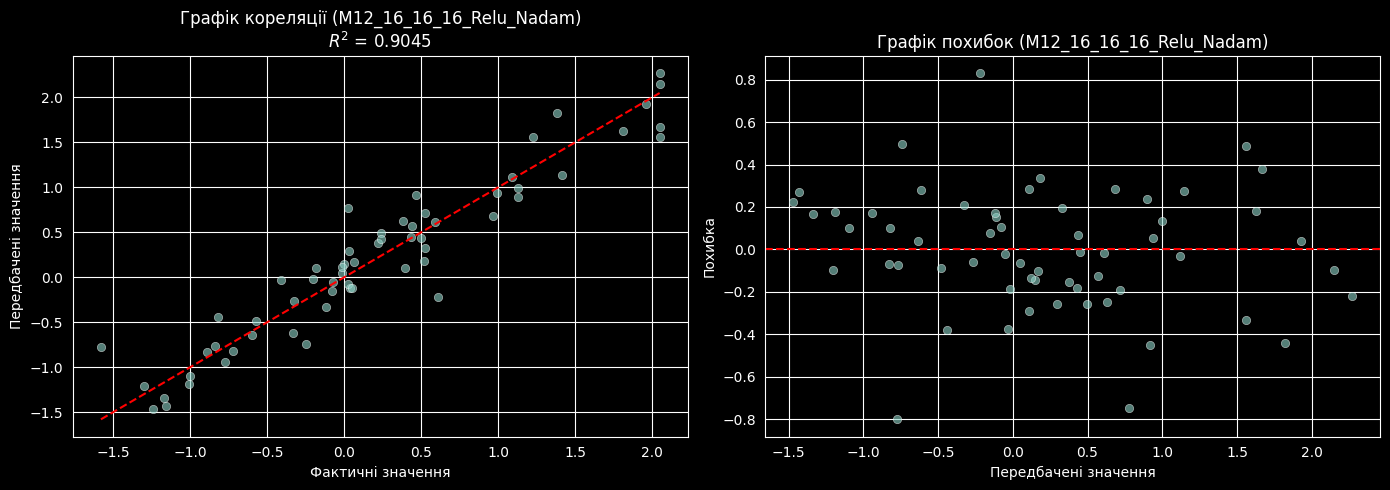

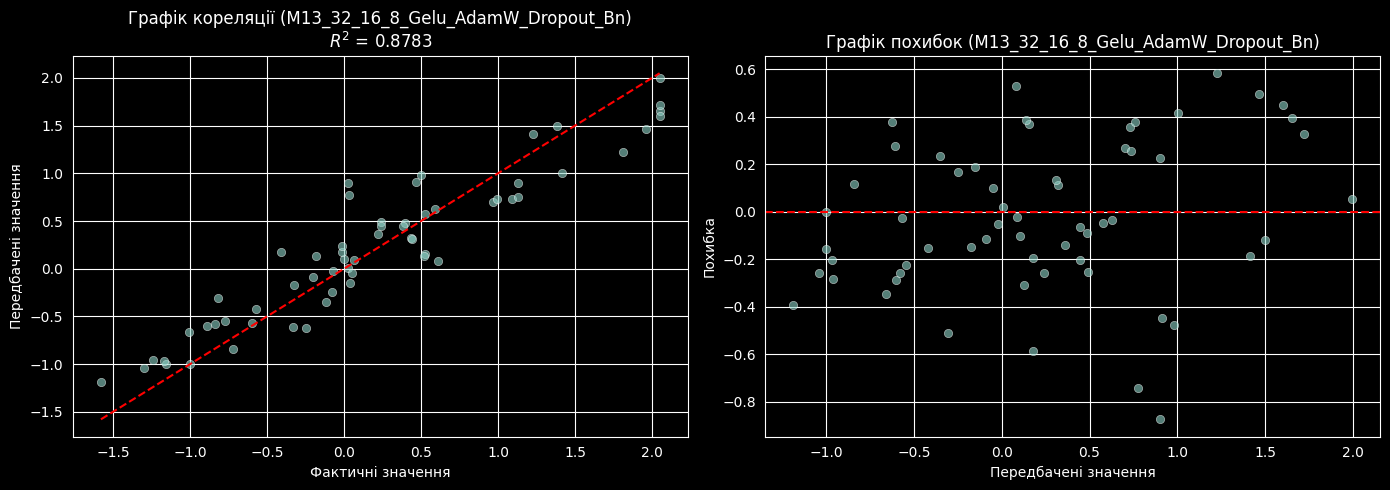

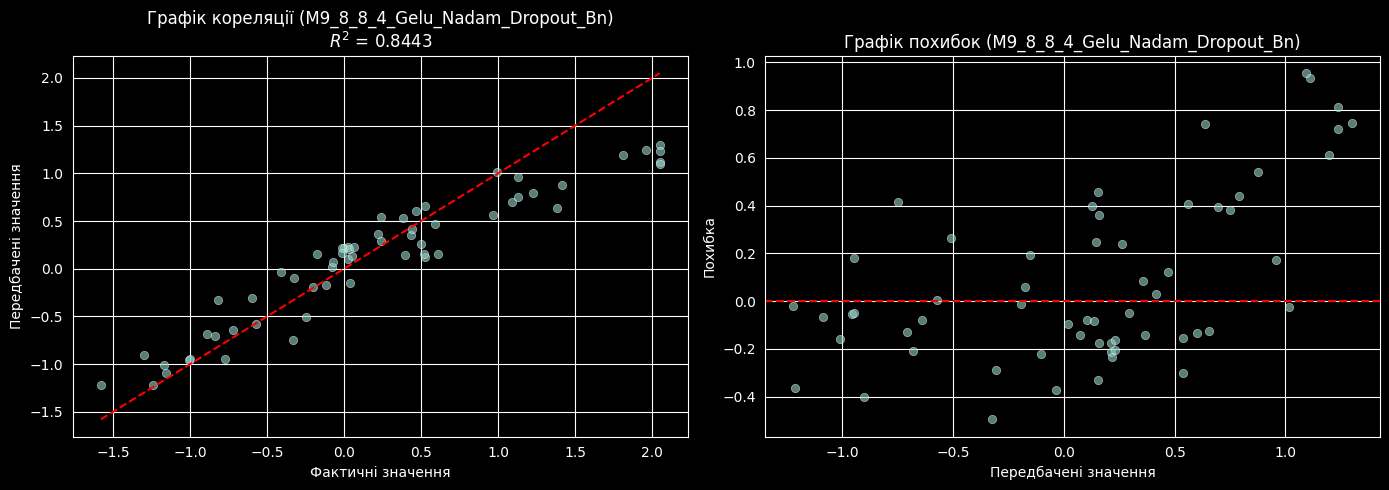

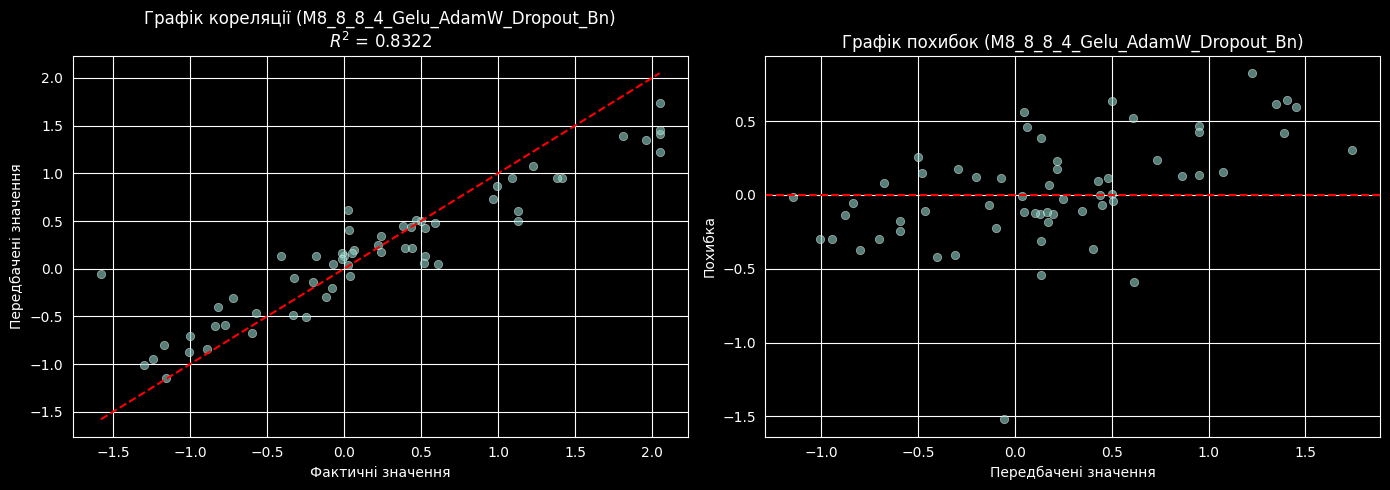

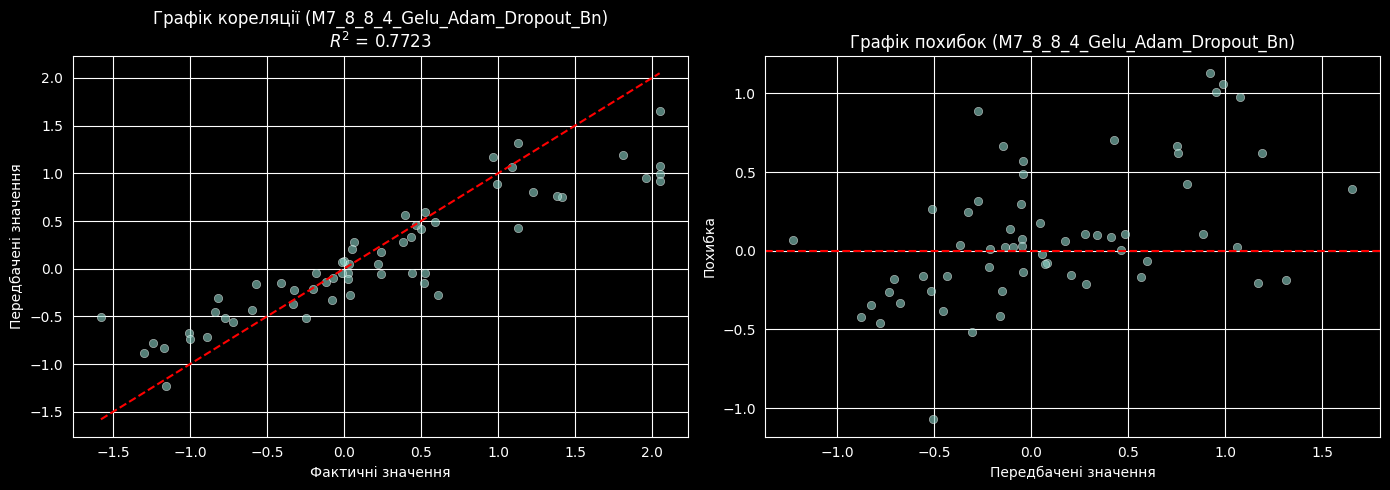

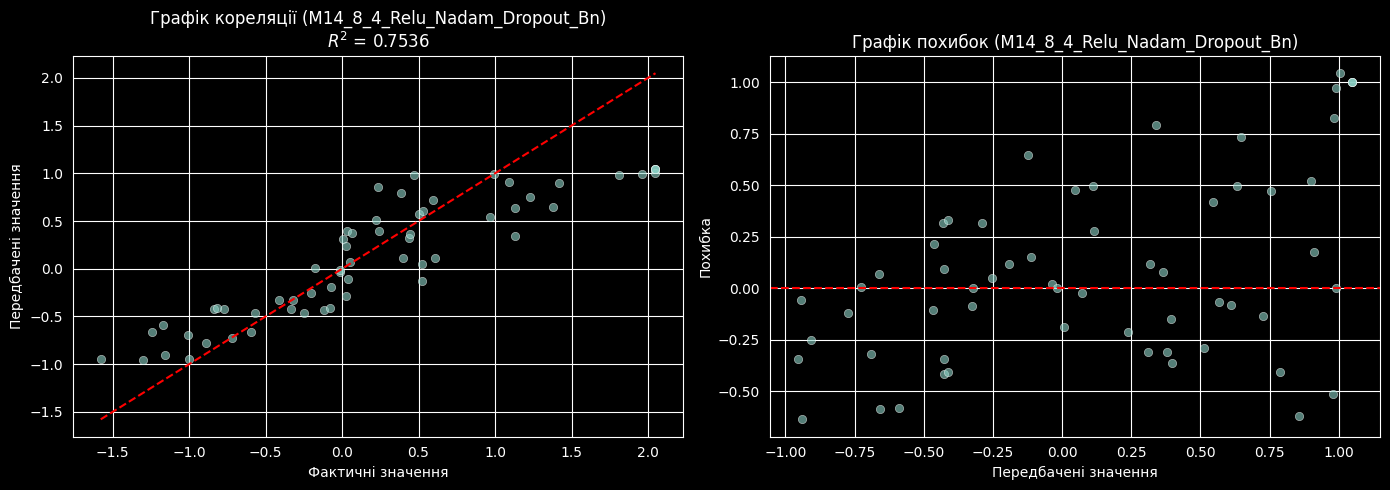

In [14]:
print("Побудова графіків...")

all_models = results_df['Model'].tolist()

for model_name in all_models:
    model, y_pred = trained_models[model_name]
    r2_val = results_df[results_df['Model'] == model_name]['R2'].values[0]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Фактичні значення")
    plt.ylabel("Передбачені значення")
    plt.title(f"Графік кореляції ({model_name})\n$R^2$ = {r2_val:.4f}")

    residuals = y_test - y_pred
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Передбачені значення")
    plt.ylabel("Похибка")
    plt.title(f"Графік похибок ({model_name})")

    plt.tight_layout()
    plt.show()